# Camera Calibration & 3D Basics

---

## What is Camera Calibration?

When a camera takes a picture it converts the **3D real world** into a **2D image**. This conversion is not perfect - cameras have distortions, different focal lengths, and sensor offsets.

**Camera Calibration** finds the mathematical parameters that describe how your specific camera works so you can:
- Correct lens distortion (fisheye, barrel)
- Measure real-world distances from images
- Do 3D reconstruction and AR

---

## Topics We Will Cover:
1. Pinhole Camera Model
2. Intrinsic Parameters (Camera Matrix K)
3. Extrinsic Parameters (R and t)
4. Lens Distortion
5. Checkerboard Calibration with OpenCV
6. Stereo Camera Basics

---
# Part 1: The Pinhole Camera Model

## The Concept

Imagine a dark box with a tiny hole on one side and a sensor on the other.  
Light from the outside enters through the hole and projects an inverted image on the sensor.

```
Real World point P(X,Y,Z)  →  Pinhole O  →  Image pixel p(x,y)
```

This is the simplest camera model: no lens, no distortion, pure geometry.

## The Math

$$x = f \cdot \frac{X}{Z}, \quad y = f \cdot \frac{Y}{Z}$$

- **f** = focal length in pixels
- **Z** = depth (how far the point is from the camera)

## Worked Example

Point P = (2, 3, 10), focal length f = 500 px:

$$x = 500 \times \frac{2}{10} = 100 \text{ px}$$

$$y = 500 \times \frac{3}{10} = 150 \text{ px}$$

Key insight: doubling Z halves the pixel position — farther objects appear smaller (**perspective**).

Focal length = 500 pixels
Object             3D (X,Y,Z)             2D pixel (x,y)
----------------------------------------------------------
Close  Z=5m        (0.5, 0.5, 5)             (50, 50)
Medium Z=10m       (0.5, 0.5, 10)             (25, 25)
Far    Z=20m       (0.5, 0.5, 20)             (12, 12)

Same real size (0.5m) appears smaller as Z grows — perspective!


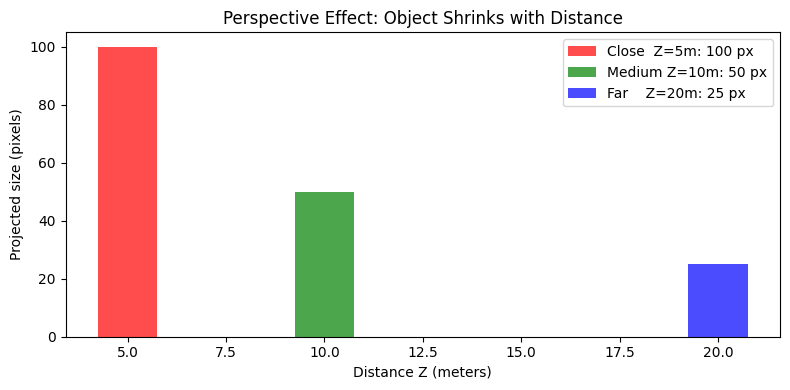

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ── Pinhole projection demo ───────────────────────────────────────────────

def pinhole_project(X, Y, Z, f=500):
    """Project a 3D point to 2D using the pinhole model."""
    return f * X / Z, f * Y / Z

f = 500
objects = [
    ('Close  Z=5m',  0.5, 0.5,  5),
    ('Medium Z=10m', 0.5, 0.5, 10),
    ('Far    Z=20m', 0.5, 0.5, 20),
]

print(f'Focal length = {f} pixels')
print(f'{"Object":<18} {"3D (X,Y,Z)":<22} {"2D pixel (x,y)"}')
print('-' * 58)
for name, X, Y, Z in objects:
    x, y = pinhole_project(X, Y, Z, f)
    print(f'{name:<18} ({X}, {Y}, {Z}){"":<12} ({x:.0f}, {y:.0f})')

print('\nSame real size (0.5m) appears smaller as Z grows — perspective!')

# Bar chart: projected size vs distance
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['red', 'green', 'blue']
for (name, X, Y, Z), color in zip(objects, colors):
    pixel_size = f * (2 * X / Z)
    ax.bar(Z, pixel_size, width=1.5, color=color, alpha=0.7,
           label=f'{name}: {pixel_size:.0f} px')
ax.set_xlabel('Distance Z (meters)')
ax.set_ylabel('Projected size (pixels)')
ax.set_title('Perspective Effect: Object Shrinks with Distance')
ax.legend()
plt.tight_layout()
plt.savefig('pinhole_perspective.png', dpi=100)
plt.show()

---
# Part 2: Intrinsic Parameters — The Camera Matrix K

## What Are Intrinsic Parameters?

They describe the **internal hardware properties** of the camera — things that stay the same no matter where you point the camera.

They are packed into the **3x3 Camera Matrix K**:

$$K = \begin{bmatrix} f_x & s & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

## Parameter Meanings

| Symbol | Name | Meaning |
|--------|------|---------|
| $f_x$ | Focal length X | Pixels per meter at 1m depth (horizontal) |
| $f_y$ | Focal length Y | Pixels per meter at 1m depth (vertical) |
| $c_x$ | Principal point X | Column of image center (≈ width/2) |
| $c_y$ | Principal point Y | Row of image center (≈ height/2) |
| $s$ | Skew | Pixel axis tilt — 0 for all modern cameras |

## Full Projection

$$u = f_x \cdot \frac{X_c}{Z_c} + c_x, \quad v = f_y \cdot \frac{Y_c}{Z_c} + c_y$$

## Worked Example

Camera 1280x720, $f_x = f_y = 800$, $c_x=640$, $c_y=360$, Point P=(0.3, 0.2, 2.0):

$$u = 800 \times 0.3/2 + 640 = 760, \quad v = 800 \times 0.2/2 + 360 = 440$$

In [12]:
import numpy as np

# ── Camera Intrinsic Matrix K demo ───────────────────────────────────────

fx, fy = 800, 800   # focal length in pixels
cx, cy = 640, 360   # principal point = image center
K = np.array([[fx,  0, cx],
              [ 0, fy, cy],
              [ 0,  0,  1]], dtype=float)

print('Camera Matrix K:')
print(K)
print()

def project(Xc, Yc, Zc, K):
    """Project camera-space point to pixel."""
    u = K[0,0] * (Xc/Zc) + K[0,2]
    v = K[1,1] * (Yc/Zc) + K[1,2]
    return u, v

test_points = [
    (0.0,  0.0, 2.0),   # center → should land at cx,cy
    (0.3,  0.2, 2.0),   # worked example
    (1.0,  0.5, 5.0),   # farther away
    (-0.5,-0.3, 3.0),   # left-below
]

print(f'{"3D point (Xc,Yc,Zc)":<28} {"2D pixel (u,v)"}')
print('-' * 50)
for pt in test_points:
    u, v = project(*pt, K)
    print(f'{str(pt):<28} ({u:.1f}, {v:.1f})')

print('\n(0,0,2) → (640,360) = image center. That is the principal point.')

Camera Matrix K:
[[800.   0. 640.]
 [  0. 800. 360.]
 [  0.   0.   1.]]

3D point (Xc,Yc,Zc)          2D pixel (u,v)
--------------------------------------------------
(0.0, 0.0, 2.0)              (640.0, 360.0)
(0.3, 0.2, 2.0)              (760.0, 440.0)
(1.0, 0.5, 5.0)              (800.0, 440.0)
(-0.5, -0.3, 3.0)            (506.7, 280.0)

(0,0,2) → (640,360) = image center. That is the principal point.


---
# Part 3: Extrinsic Parameters — Rotation R and Translation t

## What Are Extrinsic Parameters?

They describe the **position and orientation** of the camera in the world.
Unlike intrinsics, they **change every time you move the camera**.

| Parameter | Shape | Role |
|-----------|-------|------|
| Rotation Matrix **R** | 3x3 | Rotates world coords to camera coords |
| Translation Vector **t** | 3x1 | Shifts world coords to camera coords |

## Full Pipeline

```
World 3D  ──[R|t]──>  Camera 3D  ──[K]──>  Image Pixel
(Xw,Yw,Zw)            (Xc,Yc,Zc)             (u, v)
```

**Step 1 — World to Camera:**
$$P_c = R \cdot P_w + t$$

**Step 2 — Camera to Pixel:**
$$u = f_x X_c/Z_c + c_x, \quad v = f_y Y_c/Z_c + c_y$$

In [13]:
import numpy as np

# ── Extrinsic parameters demo ─────────────────────────────────────────────

K = np.array([[800, 0, 640],[0, 800, 360],[0, 0, 1]], dtype=float)

def rot_y(deg):
    """Rotation matrix around Y axis."""
    r = np.radians(deg)
    c, s = np.cos(r), np.sin(r)
    return np.array([[ c, 0, s],
                     [ 0, 1, 0],
                     [-s, 0, c]])

def world_to_pixel(Pw, K, R, t):
    """Full pipeline: 3D world point -> 2D pixel."""
    Pc = R @ Pw + t         # world -> camera coords
    Xc, Yc, Zc = Pc
    u = K[0,0] * (Xc/Zc) + K[0,2]
    v = K[1,1] * (Yc/Zc) + K[1,2]
    return u, v, Pc

Pw = np.array([0.5, 0.0, 5.0])  # tree: 0.5m right, 5m forward

# Scenario 1: camera at origin, no rotation
u1, v1, Pc1 = world_to_pixel(Pw, K, np.eye(3), np.zeros(3))

# Scenario 2: camera rotated 15 deg and shifted 1m right
u2, v2, Pc2 = world_to_pixel(Pw, K, rot_y(15), np.array([-1., 0., 0.]))

print(f'World point Pw = {Pw}')
print()
print('Scenario 1 - Camera at origin, no rotation:')
print(f'  Camera coords: {Pc1.round(3)}')
print(f'  Image pixel:   ({u1:.1f}, {v1:.1f})')
print()
print('Scenario 2 - Camera rotated 15 deg and shifted 1m right:')
print(f'  Camera coords: {Pc2.round(3)}')
print(f'  Image pixel:   ({u2:.1f}, {v2:.1f})')
print()
print('Same world point -> different pixels when camera moves!')

World point Pw = [0.5 0.  5. ]

Scenario 1 - Camera at origin, no rotation:
  Camera coords: [0.5 0.  5. ]
  Image pixel:   (720.0, 360.0)

Scenario 2 - Camera rotated 15 deg and shifted 1m right:
  Camera coords: [0.777 0.    4.7  ]
  Image pixel:   (772.3, 360.0)

Same world point -> different pixels when camera moves!


---
# Part 4: Lens Distortion

## Why Does Distortion Happen?

Real lenses are curved glass that bends light non-uniformly. Straight lines in the world appear **curved** in the image.

## Types of Distortion

| Type | k1 | Effect |
|------|-------|--------|
| Barrel | k1 < 0 | Image bows outward — common in phone cameras |
| Pincushion | k1 > 0 | Image bows inward — common in telephoto |

## The Math

For normalized image coordinates (x, y), with $r^2 = x^2 + y^2$:

**Radial distortion:**
$$x_d = x(1 + k_1 r^2 + k_2 r^4 + k_3 r^6)$$

**Tangential distortion:**
$$x_d += 2p_1 xy + p_2(r^2 + 2x^2)$$

**OpenCV distortion vector**: $(k_1, k_2, p_1, p_2, k_3)$

Calibration **measures** these 5 numbers so `cv2.undistort()` can **reverse** the bending.

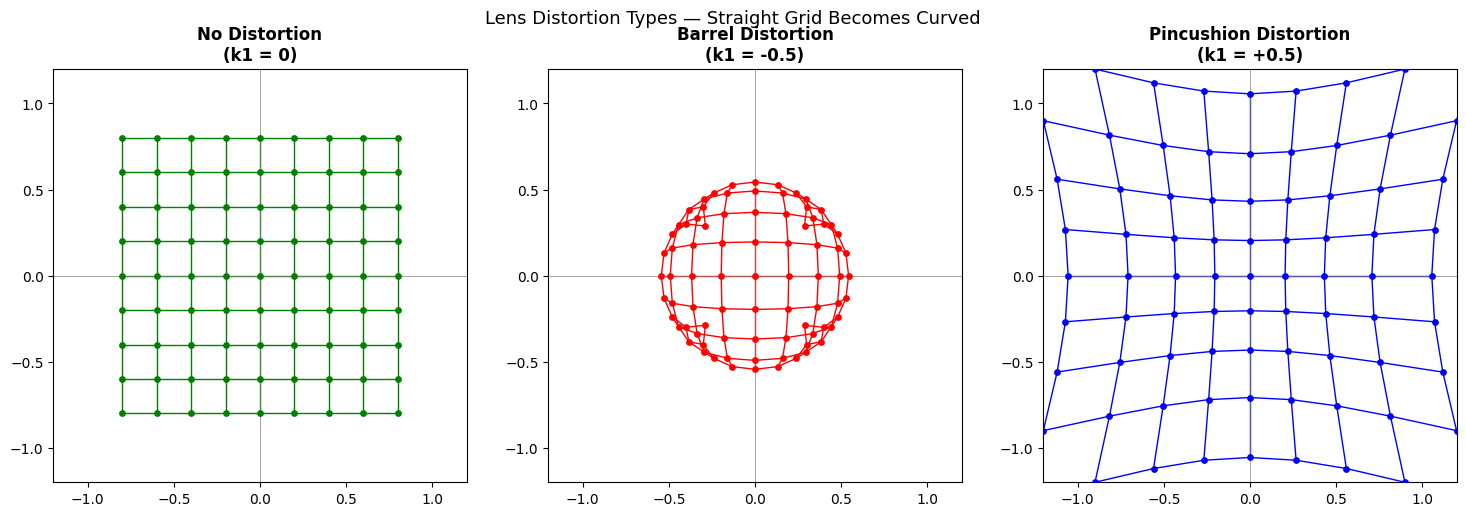

Barrel: phone/wide-angle cameras.  Pincushion: telephoto cameras.
Camera calibration measures k1,k2,p1,p2,k3 so we can UNDO this bending.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ── Visualize barrel vs pincushion distortion ─────────────────────────────

def distort_radial(x, y, k1):
    """Apply simplified radial distortion (only k1)."""
    r2 = x**2 + y**2
    return x * (1 + k1 * r2), y * (1 + k1 * r2)

g = np.linspace(-0.8, 0.8, 9)
xx, yy = np.meshgrid(g, g)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cases = [
    (0.0,  'No Distortion\n(k1 = 0)',          'green'),
    (-0.5, 'Barrel Distortion\n(k1 = -0.5)',   'red'),
    ( 0.5, 'Pincushion Distortion\n(k1 = +0.5)','blue'),
]

for ax, (k1, title, color) in zip(axes, cases):
    xd, yd = distort_radial(xx, yy, k1)
    for i in range(len(g)):
        ax.plot(xd[i, :], yd[i, :], color=color, lw=1)
        ax.plot(xd[:, i], yd[:, i], color=color, lw=1)
    ax.scatter(xd, yd, c=color, s=15, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

plt.suptitle('Lens Distortion Types — Straight Grid Becomes Curved', fontsize=13)
plt.tight_layout()
plt.savefig('lens_distortion.png', dpi=100)
plt.show()
print('Barrel: phone/wide-angle cameras.  Pincushion: telephoto cameras.')
print('Camera calibration measures k1,k2,p1,p2,k3 so we can UNDO this bending.')

---
# Part 5: Checkerboard Camera Calibration with OpenCV

## How Calibration Works

1. **Print** a checkerboard (you know each square size, e.g., 25 mm)
2. **Photograph** it from 10-20 different angles
3. OpenCV **detects the inner corners** automatically in each photo
4. It knows the **3D positions** of corners (from square size, Z=0 flat board)
5. It knows the **2D pixel positions** (from detection)
6. From many 3D→2D pairs it **solves** for K and distortion coefficients

## Key OpenCV Functions

| Function | What it does |
|----------|--------------|
| `findChessboardCorners()` | Detects inner corners of the pattern |
| `cornerSubPix()` | Refines corners to sub-pixel accuracy |
| `calibrateCamera()` | Solves for K, distortion, R, t |
| `undistort()` | Removes distortion from any image |

A **RMS reprojection error** < 1.0 px is good, < 0.5 px is excellent.

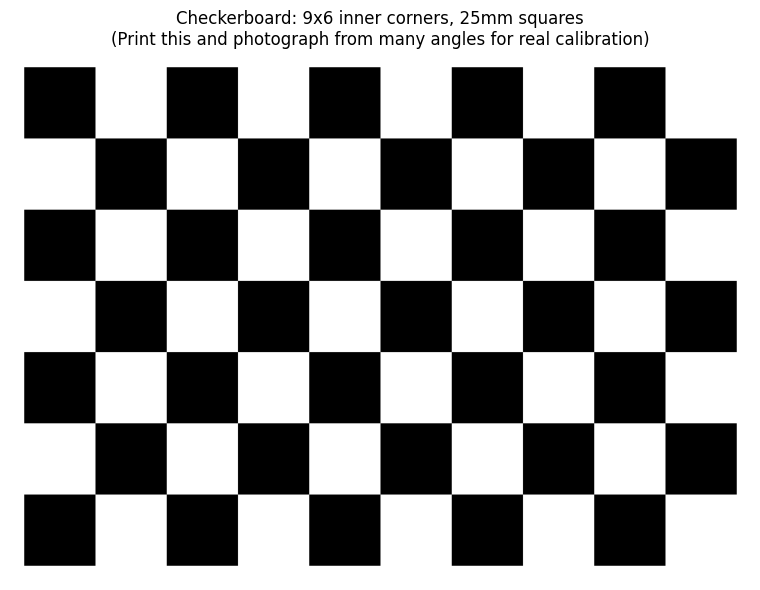

Inner corners to detect: 9 x 6 = 54 points


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Create a synthetic checkerboard ──────────────────────────────────────

ROWS, COLS, SQ = 6, 9, 50   # inner corners, square size in pixels
SQ_MM = 25                   # square size in real world (mm)

def make_checkerboard(rows, cols, sq):
    h = (rows + 1) * sq + 20
    w = (cols + 1) * sq + 20
    img = np.ones((h, w), dtype=np.uint8) * 255
    for r in range(rows + 1):
        for c in range(cols + 1):
            if (r + c) % 2 == 0:
                y1, x1 = 10 + r*sq, 10 + c*sq
                img[y1:y1+sq, x1:x1+sq] = 0
    return img

checker = make_checkerboard(ROWS, COLS, SQ)

plt.figure(figsize=(10, 6))
plt.imshow(checker, cmap='gray')
plt.title(f'Checkerboard: {COLS}x{ROWS} inner corners, {SQ_MM}mm squares\n'
          '(Print this and photograph from many angles for real calibration)')
plt.axis('off')
plt.tight_layout()
plt.savefig('checkerboard.png', dpi=100)
plt.show()
print(f'Inner corners to detect: {COLS} x {ROWS} = {COLS*ROWS} points')

Corners found: True


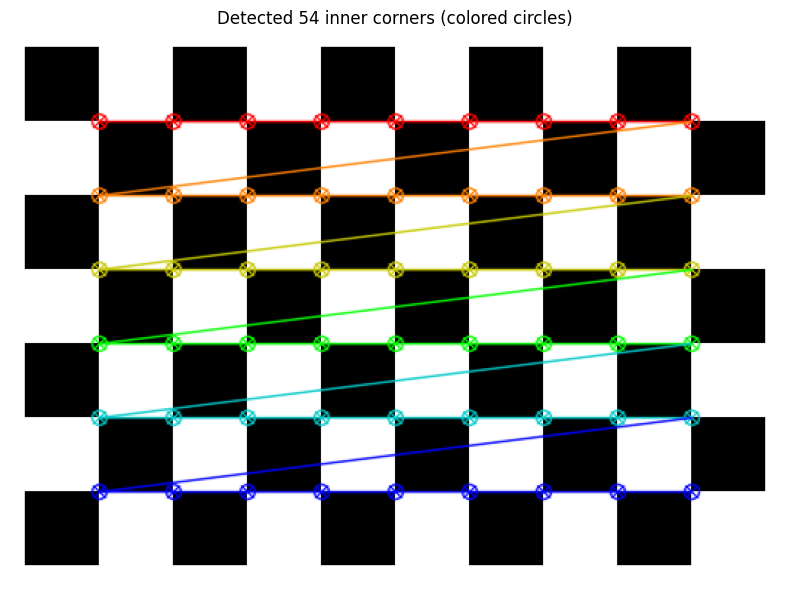

Each circle = one detected corner.
OpenCV matches these 2D detections to known 3D positions for calibration.


In [16]:
# ── Detect checkerboard corners ───────────────────────────────────────────

gray = checker.copy()
pattern = (COLS, ROWS)

ret, corners = cv2.findChessboardCorners(gray, pattern, None)
print(f'Corners found: {ret}')

if ret:
    # Sub-pixel refinement makes corner positions more precise
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

    img_color = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawChessboardCorners(img_color, pattern, corners, ret)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title(f'Detected {COLS*ROWS} inner corners (colored circles)')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('detected_corners.png', dpi=100)
    plt.show()
    print('Each circle = one detected corner.')
    print('OpenCV matches these 2D detections to known 3D positions for calibration.')
else:
    print('No corners found (normal for pure synthetic image).')
    print('Real calibration needs actual photos of a printed board.')

In [17]:
# ── Full calibration simulation ───────────────────────────────────────────
# We CREATE synthetic 2D points from a KNOWN K, then RECOVER K via calibrateCamera.

import cv2, numpy as np

IMG_W, IMG_H = 640, 480
ROWS, COLS, SQ_MM = 6, 9, 25

# TRUE parameters to recover
TRUE_K = np.array([[700., 0., 320.],[0., 700., 240.],[0., 0., 1.]], dtype=np.float64)
TRUE_DIST = np.array([[-0.15, 0.05, 0., 0., 0.]])

# 3D object points: flat board on Z=0 plane
objp = np.zeros((ROWS * COLS, 3), dtype=np.float32)
objp[:, :2] = np.mgrid[0:COLS, 0:ROWS].T.reshape(-1, 2) * SQ_MM

# 12 simulated camera poses
poses = [
    (np.array([ 0.1,  0.1, 0.0]), np.array([-100., -75., 600.])),
    (np.array([-0.1,  0.2, 0.0]), np.array([  50., -75., 640.])),
    (np.array([ 0.2, -0.1, 0.0]), np.array([-100.,  50., 560.])),
    (np.array([-0.2, -0.2, 0.0]), np.array([  50.,  50., 700.])),
    (np.array([ 0.3,  0.0, 0.1]), np.array([   0., -50., 580.])),
    (np.array([ 0.0,  0.3, 0.1]), np.array([   0.,  50., 620.])),
    (np.array([-0.3,  0.1, 0.0]), np.array([ -50., -50., 680.])),
    (np.array([ 0.1, -0.3, 0.0]), np.array([  50.,  25., 560.])),
    (np.array([ 0.2,  0.2, 0.1]), np.array([ -75.,  75., 640.])),
    (np.array([-0.1, -0.1, 0.0]), np.array([  25., -25., 590.])),
    (np.array([ 0.0,  0.1, 0.2]), np.array([ -25.,  25., 660.])),
    (np.array([ 0.1,  0.0,-0.1]), np.array([  75., -75., 610.])),
]

obj_pts, img_pts = [], []
for rvec, tvec in poses:
    pts2d, _ = cv2.projectPoints(
        objp.reshape(-1,1,3),
        rvec.astype(np.float64),
        tvec.reshape(3,1).astype(np.float64),
        TRUE_K, TRUE_DIST)
    xs, ys = pts2d[:,0,0], pts2d[:,0,1]
    if xs.min() > 0 and xs.max() < IMG_W and ys.min() > 0 and ys.max() < IMG_H:
        obj_pts.append(objp)
        img_pts.append(pts2d.astype(np.float32))

print(f'Valid views: {len(obj_pts)} / {len(poses)}')

rms, K_est, dist_est, rvecs_est, tvecs_est = cv2.calibrateCamera(
    obj_pts, img_pts, (IMG_W, IMG_H), None, None)

print(f'\nRMS reprojection error: {rms:.4f} px (< 1.0 good, < 0.5 excellent)')
print('\nTRUE K:\n', TRUE_K)
print('\nESTIMATED K:\n', K_est.round(2))
print('\nTRUE dist:    ', TRUE_DIST)
print('ESTIMATED dist:', dist_est.round(4))

Valid views: 11 / 12

RMS reprojection error: 0.0000 px (< 1.0 good, < 0.5 excellent)

TRUE K:
 [[700.   0. 320.]
 [  0. 700. 240.]
 [  0.   0.   1.]]

ESTIMATED K:
 [[700.   0. 320.]
 [  0. 700. 240.]
 [  0.   0.   1.]]

TRUE dist:     [[-0.15  0.05  0.    0.    0.  ]]
ESTIMATED dist: [[-0.15  0.05  0.    0.    0.  ]]


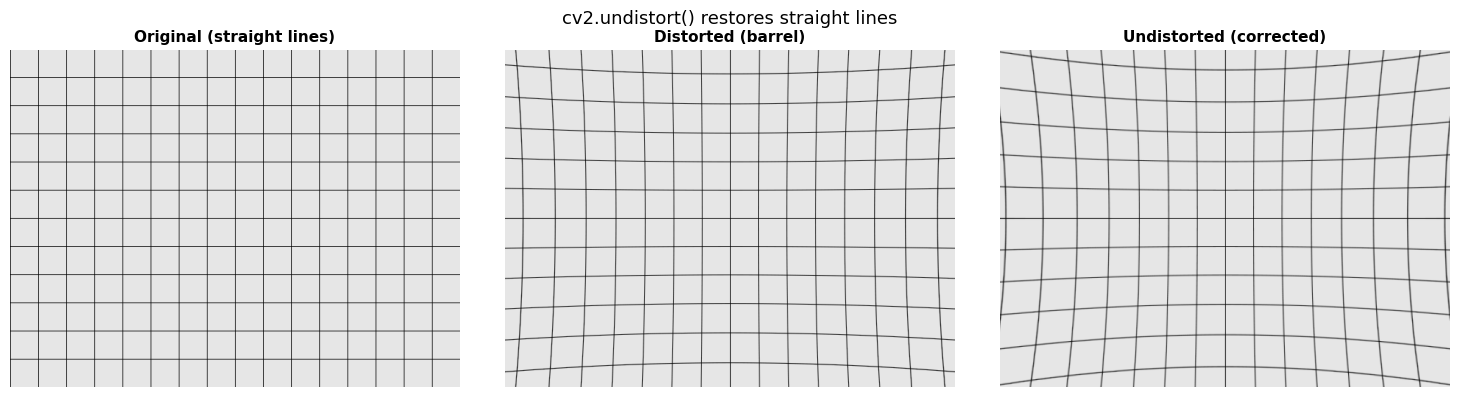

In [18]:
# ── Undistort a test image ────────────────────────────────────────────────

import cv2, numpy as np, matplotlib.pyplot as plt

def grid_image(h=480, w=640, step=40):
    """White image with black grid lines -- easy to see distortion."""
    img = np.ones((h, w, 3), dtype=np.uint8) * 230
    for y in range(0, h, step): img[y, :] = 0
    for x in range(0, w, step): img[:, x] = 0
    return img

clean = grid_image()

# Distort it to simulate barrel distortion camera
fake_K    = np.array([[700.,0.,320.],[0.,700.,240.],[0.,0.,1.]])
fake_dist = np.array([[-0.3, 0.1, 0., 0., 0.]])

map1, map2 = cv2.initUndistortRectifyMap(
    fake_K, fake_dist, None, fake_K, (640,480), cv2.CV_32FC1)
distorted = cv2.remap(clean, map1, map2, cv2.INTER_LINEAR)

undistorted = cv2.undistort(distorted, fake_K, fake_dist)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, title in zip(axes,
        [clean, distorted, undistorted],
        ['Original (straight lines)', 'Distorted (barrel)', 'Undistorted (corrected)']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle('cv2.undistort() restores straight lines', fontsize=13)
plt.tight_layout()
plt.savefig('undistortion.png', dpi=100)
plt.show()

---
# Part 6: Stereo Camera Basics

## The Idea

Two cameras side by side (like human eyes) see the same scene from slightly different angles.  
By measuring how much each point **shifted** between the two images (**disparity**) we get depth.

```
Left Camera        Right Camera
    📷──────────────────📷
    |<──── Baseline B ──>|
    |                    |
    |      P (object)    |
    p_L                 p_R

Disparity  d = x_L - x_R
```

## Depth Formula

$$\boxed{Z = \frac{f \cdot B}{d}}$$

| Symbol | Meaning |
|--------|---------|
| Z | Depth in meters |
| f | Focal length in pixels |
| B | Baseline — distance between cameras (meters) |
| d | Disparity — pixel difference between left and right |

## Worked Example

B = 0.12 m, f = 600 px, x_L = 350, x_R = 320 → d = 30 px

$$Z = \frac{600 \times 0.12}{30} = 2.4 \text{ meters}$$

- **Large disparity** → object is **close**
- **Small disparity** → object is **far**

f = 600 px | B = 12 cm

Disparity (px)     Depth (m)    Label
------------------------------------------
60                 1.20         close
40                 1.80         close
30                 2.40         medium
20                 3.60         medium
15                 4.80         medium
10                 7.20         far
5                  14.40        far
2                  36.00        far


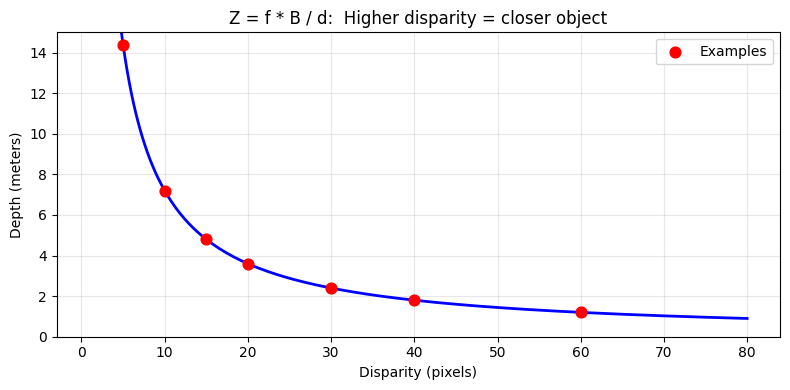

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ── Stereo depth formula demo ─────────────────────────────────────────────

f = 600     # focal length pixels
B = 0.12    # 12 cm baseline

def stereo_depth(d, f, B):
    return (f * B / d) if d > 0 else float('inf')

disparities = [60, 40, 30, 20, 15, 10, 5, 2]
depths = [stereo_depth(d, f, B) for d in disparities]

print(f'f = {f} px | B = {B*100:.0f} cm')
print()
print(f'{"Disparity (px)":<18} {"Depth (m)":<12} Label')
print('-' * 42)
for d, Z in zip(disparities, depths):
    label = 'very close' if Z < 1 else 'close' if Z < 2 else 'medium' if Z < 5 else 'far'
    print(f'{d:<18} {Z:<12.2f} {label}')

# Plot disparity vs depth
d_range = np.linspace(1, 80, 300)
z_range = f * B / d_range
plt.figure(figsize=(8, 4))
plt.plot(d_range, z_range, 'b-', lw=2)
plt.scatter(disparities, depths, color='red', s=60, zorder=5, label='Examples')
plt.xlabel('Disparity (pixels)')
plt.ylabel('Depth (meters)')
plt.title('Z = f * B / d:  Higher disparity = closer object')
plt.ylim(0, 15); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stereo_depth.png', dpi=100)
plt.show()

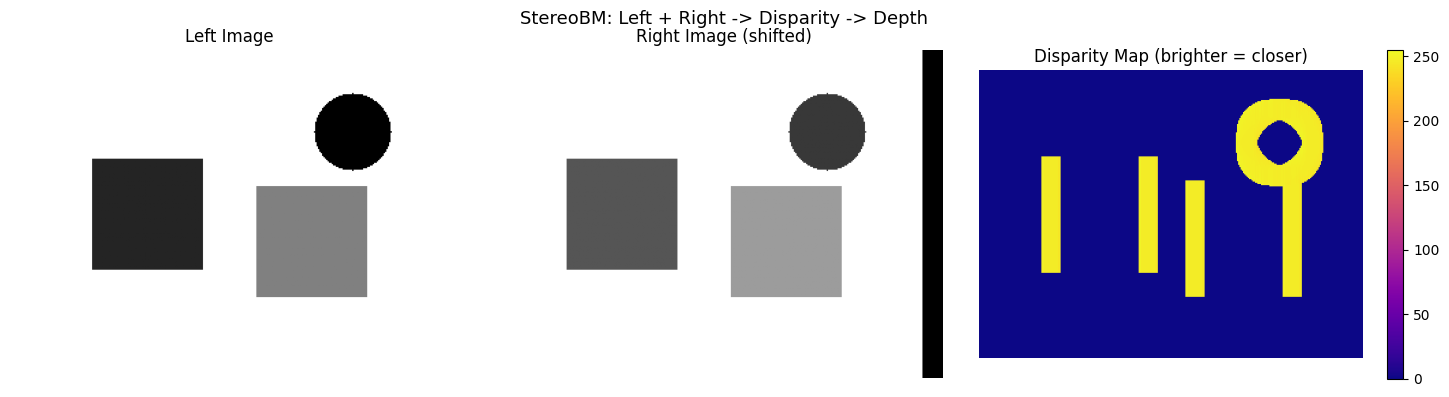

StereoBM slides a patch across both images and finds the best match.
Pixel shift = disparity.  Z = f*B/d gives depth.


In [20]:
import cv2, numpy as np, matplotlib.pyplot as plt

# ── Stereo Block Matching (StereoBM) demo ────────────────────────────────

def make_scene(shift=0):
    """Synthetic grayscale scene; shift simulates stereo baseline."""
    img = np.ones((240, 320), dtype=np.uint8) * 180
    cv2.rectangle(img, (60, 80),  (140, 160), 60, -1)
    cv2.rectangle(img, (180, 100),(260, 180), 110, -1)
    cv2.circle(img, (250, 60), 28, 40, -1)
    if shift:
        M = np.float32([[1, 0, -shift],[0, 1, 0]])
        img = cv2.warpAffine(img, M, (320, 240))
    return img

left  = make_scene(shift=0)
right = make_scene(shift=15)  # 15-px offset simulates baseline

stereo   = cv2.StereoBM_create(numDisparities=32, blockSize=15)
disp     = stereo.compute(left, right)
disp_vis = cv2.normalize(disp, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(left,     cmap='gray');   axes[0].set_title('Left Image');           axes[0].axis('off')
axes[1].imshow(right,    cmap='gray');   axes[1].set_title('Right Image (shifted)'); axes[1].axis('off')
im = axes[2].imshow(disp_vis, cmap='plasma')
axes[2].set_title('Disparity Map (brighter = closer)');  axes[2].axis('off')
plt.colorbar(im, ax=axes[2])
plt.suptitle('StereoBM: Left + Right -> Disparity -> Depth', fontsize=13)
plt.tight_layout()
plt.savefig('stereo_matching.png', dpi=100)
plt.show()
print('StereoBM slides a patch across both images and finds the best match.')
print('Pixel shift = disparity.  Z = f*B/d gives depth.')

---
# Summary

| Topic | Key Idea | Key Formula |
|-------|----------|-------------|
| Pinhole model | Light through one point | $x = f X/Z$ |
| Intrinsic matrix K | Camera hardware parameters | $u = f_x X/Z + c_x$ |
| Extrinsic [R|t] | Camera pose in world | $P_c = R P_w + t$ |
| Lens distortion | Bending by imperfect lens | $x_d = x(1+k_1 r^2)$ |
| Checkerboard calibration | Recover K and distortion | `cv2.calibrateCamera()` |
| Stereo depth | Depth from two-camera disparity | $Z = fB/d$ |

## Quick Reference

```python
import cv2

# Detect corners
ret, corners = cv2.findChessboardCorners(gray, (cols, rows), None)
corners = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

# Calibrate
rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    obj_pts, img_pts, (w, h), None, None)

# Undistort
undistorted = cv2.undistort(image, K, dist)

# Stereo
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)
disparity = stereo.compute(left_gray, right_gray)
depth = focal_px * baseline_m / disparity
```

---
# What I Learned

---

## File 1: Camera Calibration and 3D Basics

I learned that every camera converts the 3D real world into a 2D image, and this conversion follows simple math. The pinhole camera model is the simplest way to understand this: a 3D point gets projected to a pixel by dividing its position by its depth and multiplying by the focal length. This explains why objects far away look smaller in a photo.

I learned about intrinsic parameters, which are the internal settings of the camera that never change. They are stored in a 3x3 matrix called K. This matrix contains the focal length in pixels and the position of the image center. Together they let you calculate exactly which pixel any 3D point will land on.

I learned about extrinsic parameters, which describe where the camera is placed in the world and which direction it is pointing. These are a rotation matrix R and a translation vector t. The same object in the world will appear at different pixels in the image depending on where the camera is, and that is what R and t capture.

I learned that real lenses are not perfect. They bend light in a way that makes straight lines in the real world appear curved in the photo. This is called lens distortion. Barrel distortion makes the image bow outward, which is common in phone cameras. Pincushion distortion makes it bow inward, which is common in zoom lenses. OpenCV stores these imperfections as 5 numbers called distortion coefficients.

I learned how to calibrate a camera using a checkerboard pattern. You print a checkerboard, photograph it from many different angles, and OpenCV detects the corner points automatically. Because you know the real-world size of each square, it can figure out the camera matrix K and the distortion coefficients by comparing the detected 2D corners to their known 3D positions. After calibration you can call cv2.undistort to straighten any distorted photo from that camera.

I learned the basics of stereo cameras. Two cameras placed side by side see the same scene from slightly different positions. An object appears shifted by a different amount in the left and right images depending on how far away it is. This shift is called disparity. The formula Z equals f times B divided by d tells you the depth of any point. Closer objects have large disparity and far objects have small disparity. OpenCV has StereoBM which automatically finds this disparity for every pixel in the image.

---

## File 2: Motion Security System

I learned how to build a motion detection security system step by step.

The first thing I learned is background subtraction. When a camera is fixed in one place, the background stays the same frame to frame. OpenCV can build a model of this background and then mark any pixel that looks different as foreground, meaning something is moving. The MOG2 method does this by modeling each pixel with a probability distribution and flagging pixels that fall outside it. It can also detect shadows separately.

I learned that the raw foreground mask from background subtraction is noisy. There are tiny white specks everywhere that are just camera noise and not real motion. To clean this up I use morphological operations. MORPH_OPEN removes the tiny specks, MORPH_CLOSE fills holes inside detected objects, and dilation grows the blobs so nearby pieces merge together.

I learned about contour detection. After the mask is clean, cv2.findContours finds the outline of each white blob. I can check the area of each contour and ignore anything smaller than a threshold. For real objects I draw a bounding box and find the center point.

I learned about Region of Interest masking. In a real security camera you do not want to trigger an alert when a tree outside the window sways in the wind. You only want to watch a specific zone like a doorway. I create a black image the same size as the frame and draw white shapes where I want to monitor. Then I use cv2.bitwise_and to keep only the foreground detections that fall inside that zone.

I learned how to build an alert state machine with three filters. The first filter ignores blobs that are too small. The second filter requires the motion to be present for several consecutive frames before alerting, so a single noisy frame does not trigger a false alarm. The third filter is a cooldown period so the system does not spam alerts for the same ongoing event.

I learned how to save video clips using cv2.VideoWriter. When an alert fires, I create a video file and write frames to it until the motion stops plus a few extra seconds. This gives you a clip showing what happened with some context before and after.

I learned how to log events to a CSV file using Python. Every time an alert fires, I write a row with the timestamp, the path to the saved clip, and the size of the detected motion. This gives you a permanent record of all security events.

Finally I put everything together into one system that reads from a webcam or a video file, applies all the steps in order, shows a live annotated display, saves clips automatically, and logs every event. The whole system can be controlled by just a few configuration numbers at the top.